In [3]:
!pip install arch --quiet

import warnings, os, math
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Statistical
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model

# ML
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import QuantileRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input, Bidirectional,
    Conv1D, LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, Reshape, Flatten, Add
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.alpha': 0.4,
    'font.size': 11, 'axes.titlesize': 13
})
print('✓ All libraries loaded')

✓ All libraries loaded


## 1. Data Loading & Preparation

In [5]:
import os # Added to resolve NameError
import pandas as pd # Added to resolve NameError

# ── Load eurusd_hour.csv ─────────────────────────────────────────────────────
# Upload eurusd_hour.csv to /content/ in Colab (Files panel → Upload)

CSV_PATHS = ['/content/eurusd_hour.csv']

df_raw = None
for p in CSV_PATHS:
    if os.path.exists(p):
        print(f'Found: {p}')
        df_raw = pd.read_csv(p) # Changed from pd.read_excel(p) to pd.read_csv(p)
        break

if df_raw is None:
    raise FileNotFoundError(
        'eurusd_hour.csv not found. '
        'In Colab: click Files (folder icon) → Upload → select eurusd_hour.csv'
    )

# Combine Date + Time into a datetime index
df_raw['Datetime'] = pd.to_datetime(df_raw['Date'].astype(str) + ' ' + df_raw['Time'].astype(str))
df_raw = df_raw.set_index('Datetime').sort_index()

# Use BC (Bid Close) as the price series
df = df_raw[['BC']].rename(columns={'BC': 'Close'}).copy()
df.dropna(inplace=True);

# Resample to daily (take last hourly close of each day) to reduce data size
# This keeps ~3800 daily bars — ideal for training speed on Colab
df = df.resample('D').last().dropna()
df.index.name = 'Date'

# Filter data to 2015-2020 as requested by the user
df = df.loc['2015-01-01':'2020-12-31']

# Feature engineering
df['Log_Return']      = np.log(df['Close'] / df['Close'].shift(1))
df['Rolling_Std_20']  = df['Log_Return'].rolling(20).std()
df['Rolling_Mean_20'] = df['Close'].rolling(20).mean()
df.dropna(inplace=True)

print(f'✓ Loaded {len(df):,} daily bars  |  {df.index[0].date()} → {df.index[-1].date()}')
print(f'  Price range: {df.Close.min():.4f} – {df.Close.max():.4f}')
df.tail()

Found: /content/eurusd_hour.csv
✓ Loaded 1,629 daily bars  |  2015-01-25 → 2020-04-29
  Price range: 1.0390 – 1.2510


,Close,Log_Return,Rolling_Std_20,Rolling_Mean_20
Date,,,,
2020-04-24,1.08182,0.004113,0.004435,1.086458
2020-04-26,1.08198,0.000148,0.003890,1.086332
2020-04-27,1.08239,0.000379,0.003775,1.086448
2020-04-28,1.08319,0.000739,0.003777,1.086585
2020-04-29,1.08743,0.003907,0.003865,1.086967


##  Model 1. — Quantile Regression

## Model 3. — LSTM

In [10]:
# Scale data for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices.reshape(-1, 1))

def create_sequences(data, n_lags):
    X, y = [], []
    for i in range(len(data) - n_lags):
        X.append(data[i:(i + n_lags), 0])
        y.append(data[i + n_lags, 0])
    return np.array(X), np.array(y)

# Create sequences for LSTM
X_all_l, y_all_l = create_sequences(scaled_prices, N_LAGS)

# Split data for LSTM
split_l = int(len(X_all_l) * 0.80)
X_tr_l, X_te_l = X_all_l[:split_l], X_all_l[split_l:]
y_tr_l, y_te_l = y_all_l[:split_l], y_all_l[split_l:]

# Reshape data for LSTM [samples, timesteps, features]
X_tr_l = X_tr_l.reshape(X_tr_l.shape[0], X_tr_l.shape[1], 1)
X_te_l = X_te_l.reshape(X_te_l.shape[0], X_te_l.shape[1], 1)

# Get corresponding dates and actual prices for test set
lstm_dates = dates[N_LAGS:][split_l:]
actual_prices_l = scaler.inverse_transform(y_te_l.reshape(-1, 1)).flatten()

print(f'LSTM Training data shape: X={X_tr_l.shape}, y={y_tr_l.shape}')
print(f'LSTM Test data shape: X={X_te_l.shape}, y={y_te_l.shape}')

LSTM Training data shape: X=(1291, 15, 1), y=(1291,)
LSTM Test data shape: X=(323, 15, 1), y=(323,)


In [11]:
# Build LSTM Model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(N_LAGS, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Train LSTM Model
history = lstm_model.fit(
    X_tr_l, y_tr_l,
    epochs=50, batch_size=32,
    validation_split=0.1, verbose=0,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

print('LSTM model trained successfully.')

LSTM model trained successfully.


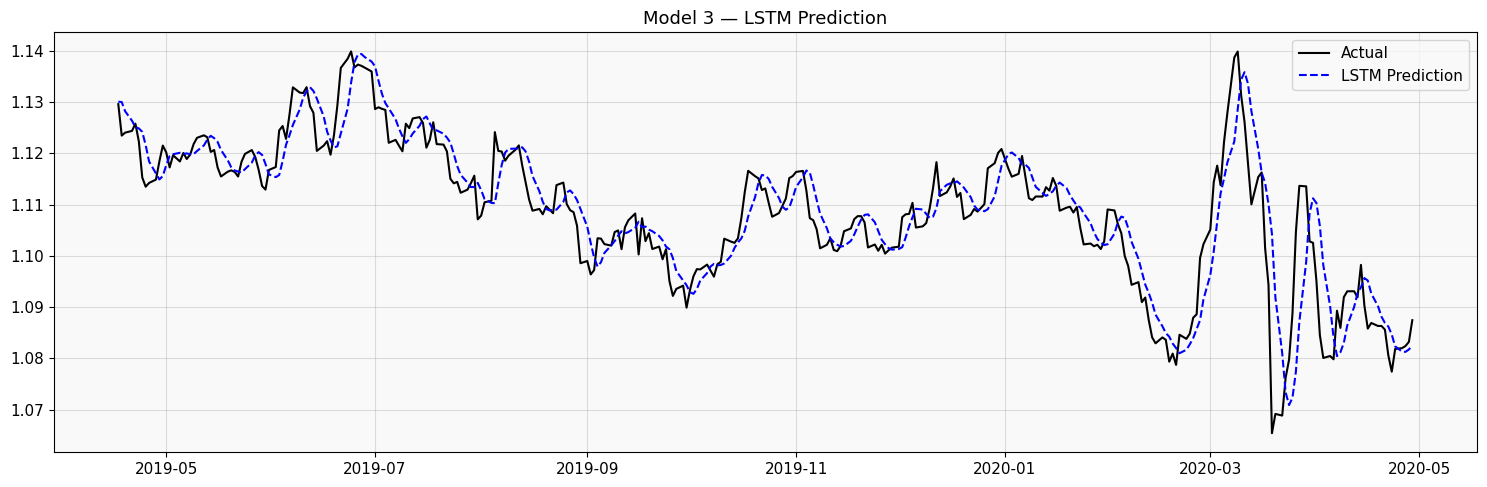

LSTM — MAE: 0.00440 | RMSE: 0.00633 | MAPE: 0.40%


In [12]:
# Make predictions
lstm_pred_scaled = lstm_model.predict(X_te_l, verbose=0)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()

# Plot LSTM results
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(lstm_dates, actual_prices_l, color='black', lw=1.5, label='Actual')
ax.plot(lstm_dates, lstm_pred, color='blue', lw=1.5, ls='--', label='LSTM Prediction')
ax.set_title('Model 3 — LSTM Prediction'); ax.legend()
plt.tight_layout(); plt.savefig('fig_lstm.png', dpi=120, bbox_inches='tight'); plt.show()

lstm_mae = mean_absolute_error(actual_prices_l, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(actual_prices_l, lstm_pred))
lstm_mape = np.mean(np.abs((actual_prices_l - lstm_pred) / actual_prices_l)) * 100
print(f'LSTM — MAE: {lstm_mae:.5f} | RMSE: {lstm_rmse:.5f} | MAPE: {lstm_mape:.2f}%')

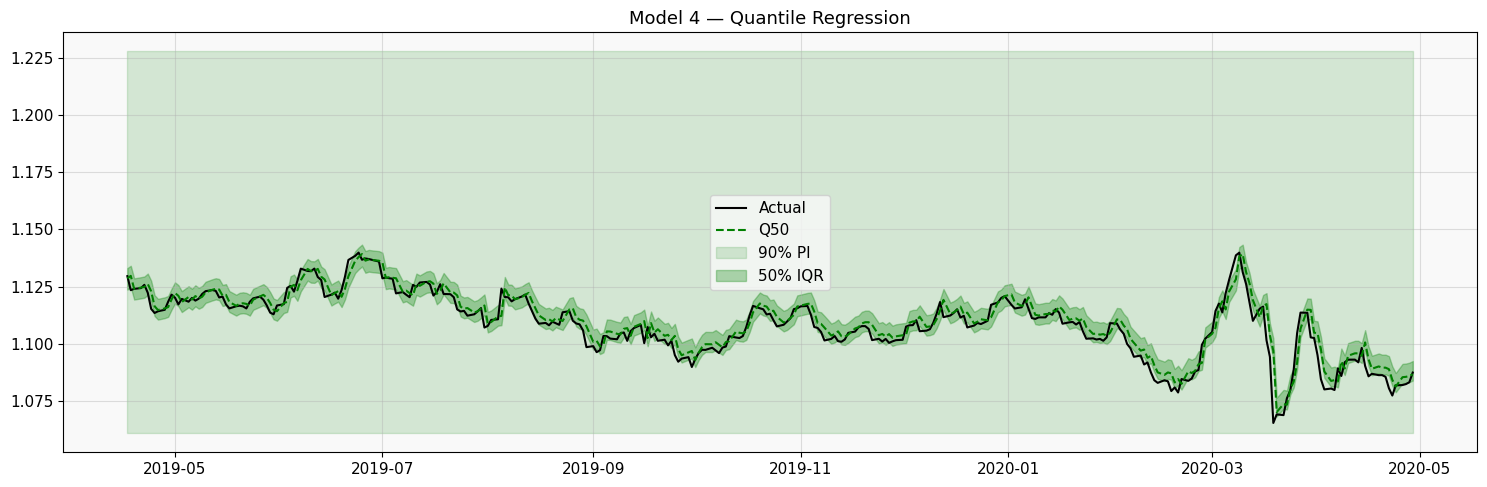

Quantile Reg — MAE: 0.00312 | RMSE: 0.00441 | MAPE: 0.28%
90% PI Coverage: 100.0%


In [7]:
N_LAGS = 15
def make_lag_features(series, n_lags):
    df_lag = pd.DataFrame({'y': series})
    for lag in range(1, n_lags + 1):
        df_lag[f'lag_{lag}'] = df_lag['y'].shift(lag)
    df_lag.dropna(inplace=True)
    return df_lag.drop('y', axis=1).values, df_lag['y'].values

prices = df['Close'].values # Define prices from the 'Close' column of the df DataFrame
dates  = df.index          # Define dates from the index of the df DataFrame

X_all, y_all = make_lag_features(prices, N_LAGS)
split_q      = int(len(X_all) * 0.80)
X_tr_q, X_te_q = X_all[:split_q], X_all[split_q:]
y_tr_q, y_te_q = y_all[:split_q], y_all[split_q:]
qr_dates       = dates[N_LAGS:][split_q:]

quantiles = [0.05, 0.25, 0.50, 0.75, 0.95]
qr_preds  ={}
for q in quantiles:
    qr = QuantileRegressor(quantile=q, alpha=0.01, solver='highs')
    qr.fit(X_tr_q, y_tr_q)
    qr_preds[q] = qr.predict(X_te_q)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(qr_dates, y_te_q, color='black', lw=1.5, label='Actual')
ax.plot(qr_dates, qr_preds[0.50], color='green', lw=1.5, ls='--', label='Q50')
ax.fill_between(qr_dates, qr_preds[0.05], qr_preds[0.95], alpha=0.15, color='green', label='90% PI')
ax.fill_between(qr_dates, qr_preds[0.25], qr_preds[0.75], alpha=0.30, color='green', label='50% IQR')
ax.set_title('Model 4 — Quantile Regression'); ax.legend()
plt.tight_layout(); plt.savefig('fig_quantile.png', dpi=120, bbox_inches='tight'); plt.show()

qr_mae  = mean_absolute_error(y_te_q, qr_preds[0.50])
qr_rmse = np.sqrt(mean_squared_error(y_te_q, qr_preds[0.50]))
qr_mape = np.mean(np.abs((y_te_q - qr_preds[0.50]) / y_te_q)) * 100
cov90_qr = np.mean((y_te_q >= qr_preds[0.05]) & (y_te_q <= qr_preds[0.95]))
print(f'Quantile Reg — MAE: {qr_mae:.5f} | RMSE: {qr_rmse:.5f} | MAPE: {qr_mape:.2f}%')
print(f'90% PI Coverage: {cov90_qr*100:.1f}%')

##  Model 3.  — Conformal Prediction

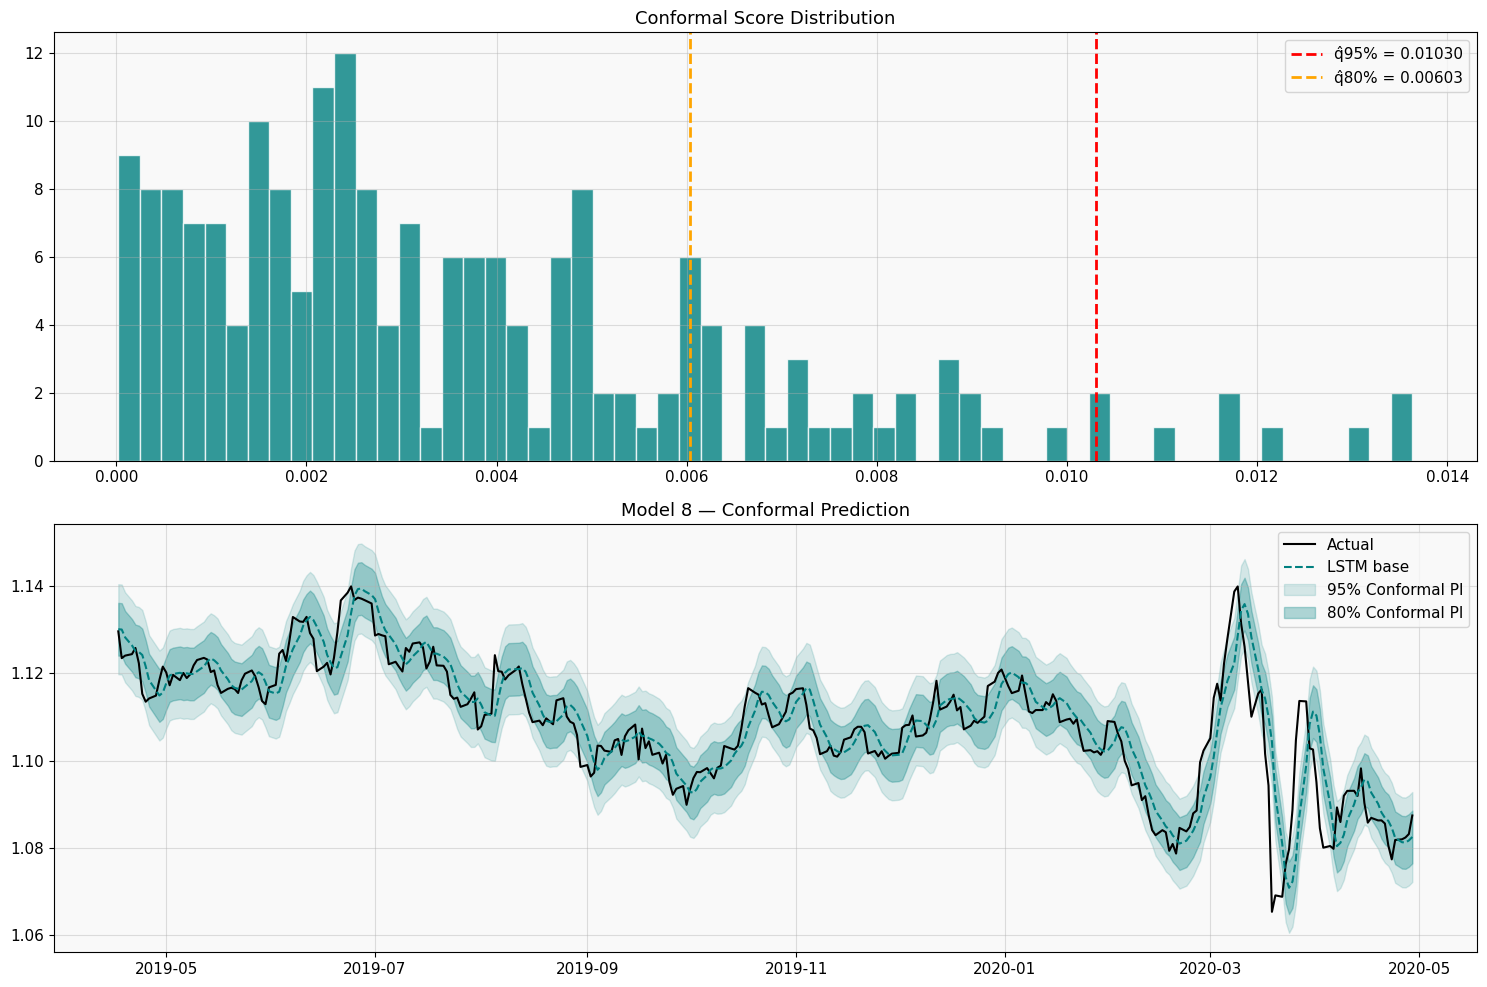

Conformal 95% Coverage: 92.9% | 80% Coverage: 76.5%


In [13]:
calib_frac  = 0.15
calib_start = int(split_l * (1 - calib_frac))
X_calib      = X_tr_l[calib_start:]
y_calib      = scaler.inverse_transform(y_tr_l[calib_start:].reshape(-1,1)).flatten()
y_calib_pred = scaler.inverse_transform(lstm_model.predict(X_calib, verbose=0)).flatten()
scores       = np.abs(y_calib - y_calib_pred)

def conformal_quantile(scores, alpha):
    n = len(scores)
    level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    return np.quantile(scores, level)

q_hat_95 = conformal_quantile(scores, 0.05)
q_hat_80 = conformal_quantile(scores, 0.20)
conf_lo95 = lstm_pred - q_hat_95; conf_hi95 = lstm_pred + q_hat_95
conf_lo80 = lstm_pred - q_hat_80; conf_hi80 = lstm_pred + q_hat_80

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
axes[0].hist(scores, bins=60, color='teal', edgecolor='white', alpha=0.8)
axes[0].axvline(q_hat_95, color='red', ls='--', lw=2, label=f'q̂95% = {q_hat_95:.5f}')
axes[0].axvline(q_hat_80, color='orange', ls='--', lw=2, label=f'q̂80% = {q_hat_80:.5f}')
axes[0].set_title('Conformal Score Distribution'); axes[0].legend()
axes[1].plot(lstm_dates, actual_prices_l, color='black', lw=1.5, label='Actual')
axes[1].plot(lstm_dates, lstm_pred, color='teal', lw=1.5, ls='--', label='LSTM base')
axes[1].fill_between(lstm_dates, conf_lo95, conf_hi95, alpha=0.15, color='teal', label='95% Conformal PI')
axes[1].fill_between(lstm_dates, conf_lo80, conf_hi80, alpha=0.30, color='teal', label='80% Conformal PI')
axes[1].set_title('Model 8 — Conformal Prediction'); axes[1].legend()
plt.tight_layout(); plt.savefig('fig_conformal.png', dpi=120, bbox_inches='tight'); plt.show()

cov95_conf = np.mean((actual_prices_l >= conf_lo95) & (actual_prices_l <= conf_hi95))
cov80_conf = np.mean((actual_prices_l >= conf_lo80) & (actual_prices_l <= conf_hi80))
print(f'Conformal 95% Coverage: {cov95_conf*100:.1f}% | 80% Coverage: {cov80_conf*100:.1f}%')